In [16]:
import pandas as pd
df=pd.read_csv('Mall_Customers (1).csv')
info=df.info()
info,df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


(None,
    CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
 0           1    Male   19                  15                      39
 1           2    Male   21                  15                      81
 2           3  Female   20                  16                       6
 3           4  Female   23                  16                      77
 4           5  Female   31                  17                      40
 5           6  Female   22                  17                      76
 6           7  Female   35                  18                       6
 7           8  Female   23                  18                      94
 8           9    Male   64                  19                       3
 9          10  Female   30                  19                      72)

In [17]:
msg_val=df.isnull().sum()
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})
df=df.drop(columns=['CustomerID'])
desc=df.describe()
msg_val,desc

(CustomerID                0
 Genre                     0
 Age                       0
 Annual Income (k$)        0
 Spending Score (1-100)    0
 dtype: int64,
             Genre         Age  Annual Income (k$)  Spending Score (1-100)
 count  200.000000  200.000000          200.000000              200.000000
 mean     0.560000   38.850000           60.560000               50.200000
 std      0.497633   13.969007           26.264721               25.823522
 min      0.000000   18.000000           15.000000                1.000000
 25%      0.000000   28.750000           41.500000               34.750000
 50%      1.000000   36.000000           61.500000               50.000000
 75%      1.000000   49.000000           78.000000               73.000000
 max      1.000000   70.000000          137.000000               99.000000)

In [18]:
data=df.copy()
for col in ['Age','Annual Income (k$)','Spending Score (1-100)']:
    Q1=data[col].quantile(0.25)
    Q3=data[col].quantile(0.75)
    IQR=Q3-Q1
    low_bound=Q1-1.5*IQR
    up_bound=Q3+1.5*IQR
    data=data[(data[col]>=low_bound)&(data[col]<=up_bound)]
def min_max(column):
    min_val=column.min()
    max_val=column.max()
    return (column-min_val)/(max_val-min_val)
for col in data.columns:
    data[col] = min_max(data[col])
data

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0.0,0.019231,0.000000,0.387755
1,0.0,0.057692,0.000000,0.816327
2,1.0,0.038462,0.009009,0.051020
3,1.0,0.096154,0.009009,0.775510
4,1.0,0.250000,0.018018,0.397959
...,...,...,...,...
193,1.0,0.384615,0.882883,0.918367
194,1.0,0.557692,0.945946,0.153061
195,1.0,0.326923,0.945946,0.795918
196,1.0,0.519231,1.000000,0.275510


In [19]:
import numpy as np
import random
arr = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].to_numpy()
num_clusters=5
random.seed(42)
centers = arr[random.sample(range(len(arr)), num_clusters)]
max_iter=100
for step in range(max_iter):
    groups = [[] for _ in range(num_clusters)]
    for row in arr:
        dists = [np.linalg.norm(row - c) for c in centers]
        group_index = np.argmin(dists)
        groups[group_index].append(row)
    updated_centers = []
    for grp in groups:
        if grp:
            updated_centers.append(np.mean(grp, axis=0))
        else:
            updated_centers.append(arr[random.randint(0, len(arr) - 1)])

    updated_centers = np.array(updated_centers)
    if np.allclose(centers, updated_centers):
        print(f"The algorithm was completed in step {step}")
        break
    centers = updated_centers

The algorithm was completed in step 9


In [20]:
import numpy as np
import random
arr = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].to_numpy()
num_clusters = 8
random.seed(42)
centers = arr[random.sample(range(len(arr)), num_clusters)]
max_iter=100
for step in range(max_iter):
    groups = [[] for _ in range(num_clusters)]
    for row in arr:
        dists = [np.linalg.norm(row - c) for c in centers]
        group_index = np.argmin(dists)
        groups[group_index].append(row)
    updated_centers = []
    for grp in groups:
        if grp:
            updated_centers.append(np.mean(grp, axis=0))
        else:
            updated_centers.append(arr[random.randint(0, len(arr) - 1)])

    updated_centers = np.array(updated_centers)
    if np.allclose(centers, updated_centers):
        print(f"The algorithm was completed in step {step}")
        break
    centers = updated_centers

The algorithm was completed in step 12


In [21]:
final_centers = centers
cluster_labels = []
for row in arr:
    dists = [np.linalg.norm(row - c) for c in final_centers]
    label = np.argmin(dists)
    cluster_labels.append(label)
data['Cluster'] = cluster_labels
data

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0.0,0.019231,0.000000,0.387755,1
1,0.0,0.057692,0.000000,0.816327,7
2,1.0,0.038462,0.009009,0.051020,1
3,1.0,0.096154,0.009009,0.775510,7
4,1.0,0.250000,0.018018,0.397959,1
...,...,...,...,...,...
193,1.0,0.384615,0.882883,0.918367,0
194,1.0,0.557692,0.945946,0.153061,3
195,1.0,0.326923,0.945946,0.795918,0
196,1.0,0.519231,1.000000,0.275510,3


In [22]:
final_centers = centers
cluster_labels = []
for row in arr:
    dists = [np.linalg.norm(row - c) for c in final_centers]
    label = np.argmin(dists)
    cluster_labels.append(label)
data['Cluster'] = cluster_labels
data

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0.0,0.019231,0.000000,0.387755,1
1,0.0,0.057692,0.000000,0.816327,7
2,1.0,0.038462,0.009009,0.051020,1
3,1.0,0.096154,0.009009,0.775510,7
4,1.0,0.250000,0.018018,0.397959,1
...,...,...,...,...,...
193,1.0,0.384615,0.882883,0.918367,0
194,1.0,0.557692,0.945946,0.153061,3
195,1.0,0.326923,0.945946,0.795918,0
196,1.0,0.519231,1.000000,0.275510,3


In [23]:
def my_silhouette_score(points, cluster_marks):
    total = len(points)
    all_scores = []
    for idx in range(total):
        same_group = []
        other_groups = {}
        for j in range(total):
            if idx == j:
                continue
            distance = np.linalg.norm(points[idx] - points[j])
            if cluster_marks[idx] == cluster_marks[j]:
                same_group.append(distance)
            else:
                other_groups.setdefault(cluster_marks[j], []).append(distance)
        # a(i): средняя дистанция до точек своего кластера
        a = np.mean(same_group) if same_group else 0
        # b(i): минимальная средняя дистанция до других кластеров
        b = np.min([np.mean(g) for g in other_groups.values()]) if other_groups else 0
        # s(i): формула силуэта
        if max(a, b) == 0:
            score = 0
        else:
            score = (b - a) / max(a, b)
        all_scores.append(score)
    return np.mean(all_scores)

In [24]:
silhouette = my_silhouette_score(arr, cluster_labels)
print(f"Silhouette Score: {silhouette:.3f}")


Silhouette Score: 0.439


In [25]:
scores = []
ks = list(range(2, 11))

for k_test in ks:
    random.seed(42)
    centroids=arr[random.sample(range(len(arr)),k_test)]
    for _ in range(100):
        clusters=[[] for _ in range(k_test)]
        for point in arr:
            distances=[np.linalg.norm(point-centroid) for centroid in centroids]
            cluster_idx=np.argmin(distances)
            clusters[cluster_idx].append(point)
        new_centroids = []
        for cluster in clusters:
            if cluster:
                new_centroids.append(np.mean(cluster, axis=0))
            else:
                new_centroids.append(arr[random.randint(0, len(arr)-1)])
        new_centroids = np.array(new_centroids)

        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    labels = []
    for point in arr:
        distances = [np.linalg.norm(point - centroid) for centroid in centroids]
        labels.append(np.argmin(distances))
    score = my_silhouette_score(arr, labels)
    scores.append(score)

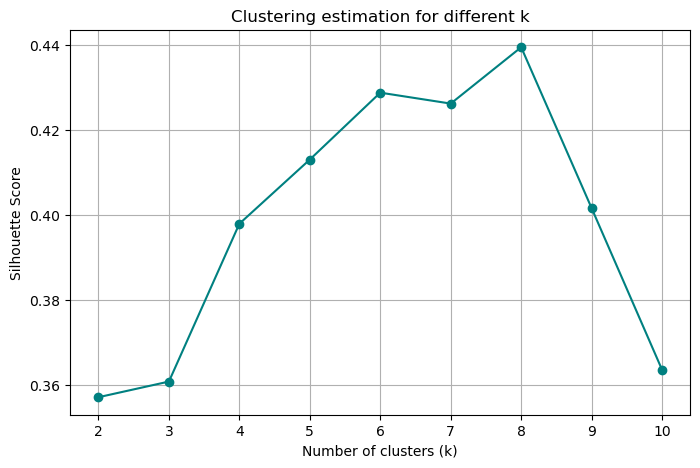

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(ks, scores, marker='o', color='teal')
plt.xticks(ks)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Clustering estimation for different k')
plt.grid(True)
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


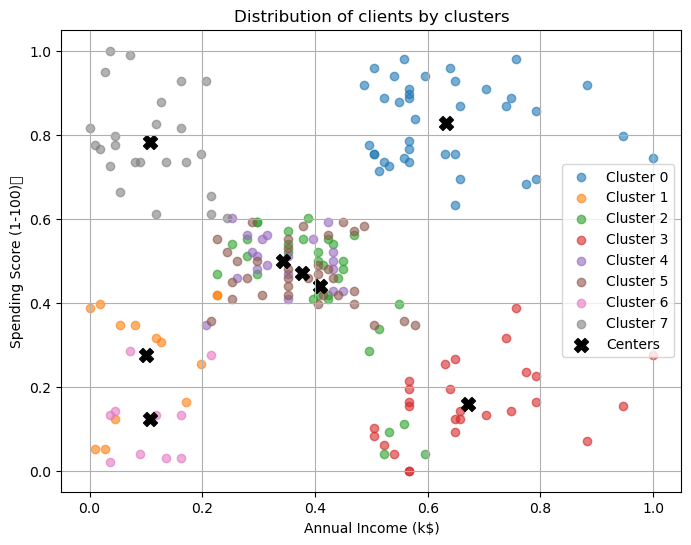

In [27]:
k = 8  # финальное число кластеров, выбранное по Silhouette Score
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
for group_id in range(k):
    group_data = data[data['Cluster'] == group_id]
    plt.scatter(group_data['Annual Income (k$)'], 
                group_data['Spending Score (1-100)'], 
                label=f'Cluster {group_id}', alpha=0.6)
centers_2d = final_centers[:, [1, 2]]
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], 
            color='black', marker='X', s=100, label='Centers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)	')
plt.title('Distribution of clients by clusters')
plt.legend()
plt.grid(True)
plt.show()

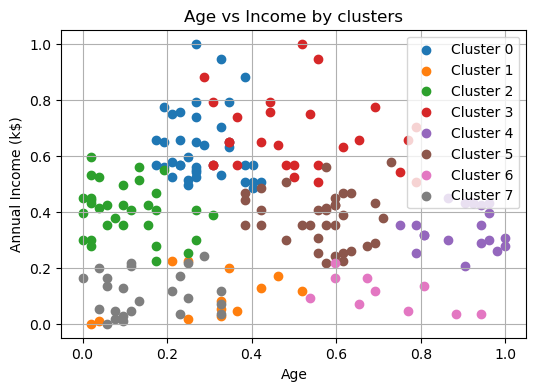

In [28]:
plt.figure(figsize=(6,4))
for cluster in range(k):
    cluster_points = arr[np.array(cluster_labels) == cluster]
    plt.scatter(cluster_points[:,0], cluster_points[:,1], label=f'Cluster {cluster}')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('Age vs Income by clusters')
plt.legend()
plt.grid(True)
plt.show()

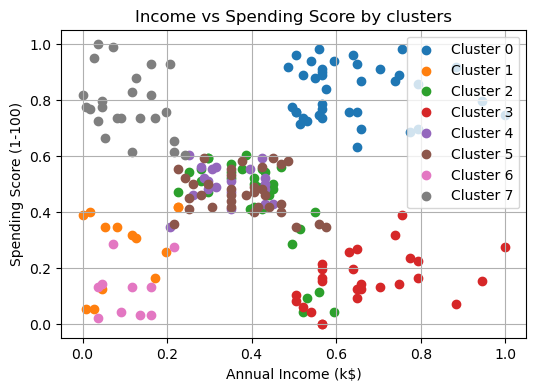

In [29]:
plt.figure(figsize=(6,4))
for cluster in range(k):
    cluster_points = arr[np.array(cluster_labels) == cluster]
    plt.scatter(cluster_points[:,1], cluster_points[:,2], label=f'Cluster {cluster}')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Income vs Spending Score by clusters')
plt.legend()
plt.grid(True)
plt.show()

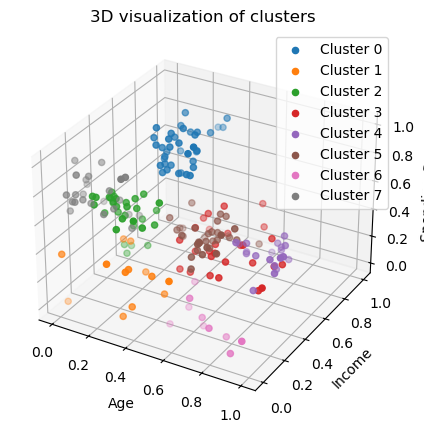

In [30]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
for cluster in range(k):
    cluster_points = arr[np.array(cluster_labels) == cluster]
    ax.scatter(cluster_points[:,0], cluster_points[:,1], cluster_points[:,2], label=f'Cluster {cluster}')
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Spending Score')
ax.set_title('3D visualization of clusters')
plt.legend()
plt.show()

In [31]:
profile = df.loc[data.index].assign(Cluster=cluster_labels).groupby('Cluster').agg(
    count=('Age','size'),
    avg_age=('Age','mean'),
    avg_income=('Annual Income (k$)','mean'),
    avg_spending=('Spending Score (1-100)','mean'),
    pct_female=('Genre','mean')
).round(1)
profile['pct_female'] = (profile['pct_female']*100).round(0)
profile.sort_values('count', ascending=False)

,count,avg_age,avg_income,avg_spending,pct_female
Cluster,,,,,
0,38,32.8,85.2,82.1,60.0
5,34,47.4,56.9,47.1,60.0
2,32,23.5,60.3,44.1,60.0
3,27,44.3,89.6,16.6,50.0
7,24,25.8,27.0,77.8,60.0
4,20,64.8,53.2,49.8,40.0
1,13,33.5,26.1,28.0,80.0
6,10,55.2,26.9,13.0,50.0
